In [1]:
import pandas as pd
import numpy as np
from mrmr import mrmr_classif
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../tissue_dataset.csv")
X = df.drop(columns = ["target", "target_actual"])
y = df["target"]
lasso_features = pd.read_csv("../results/lasso_feature_ranking.csv")
rf_importances = pd.read_csv("../results/rf_importances_ranking.csv")
mi_importances = pd.read_csv("../results/mi_importances_ranking.csv")
xgb_importances = pd.read_csv("../results/xgb_importances_ranking.csv")
type(X), type(y)

(pandas.DataFrame, pandas.Series)

In [4]:
#mRMR Model
selected_features = mrmr_classif(
    X=X,
    y=y,
    K=100
)
mrmr_ranking = pd.DataFrame({
    "Rank": range(1, len(selected_features) + 1),
    "miRNA": selected_features
})

mrmr_ranking.head(20)

100%|██████████| 100/100 [00:27<00:00,  3.58it/s]


,Rank,miRNA
0,1,168626 : hsa-miR-4662a-5p
1,2,42902 : hsa-miR-185-5p
2,3,168829 : hsa-miR-4794
3,4,147709 : hsa-miR-3185
4,5,145677 : hsa-miR-139-5p
5,6,46361 : hsa-miR-1278
6,7,168791 : hsa-miR-4785
7,8,147997 : hsa-miR-3934
8,9,30787 : hsa-miR-125b-5p
9,10,42681 : hsa-miR-1307-3p


In [5]:
#Saving Ranking list
mrmr_ranking.to_csv(
    "../results/mrmr_feature_ranking.csv",
    index=False
)

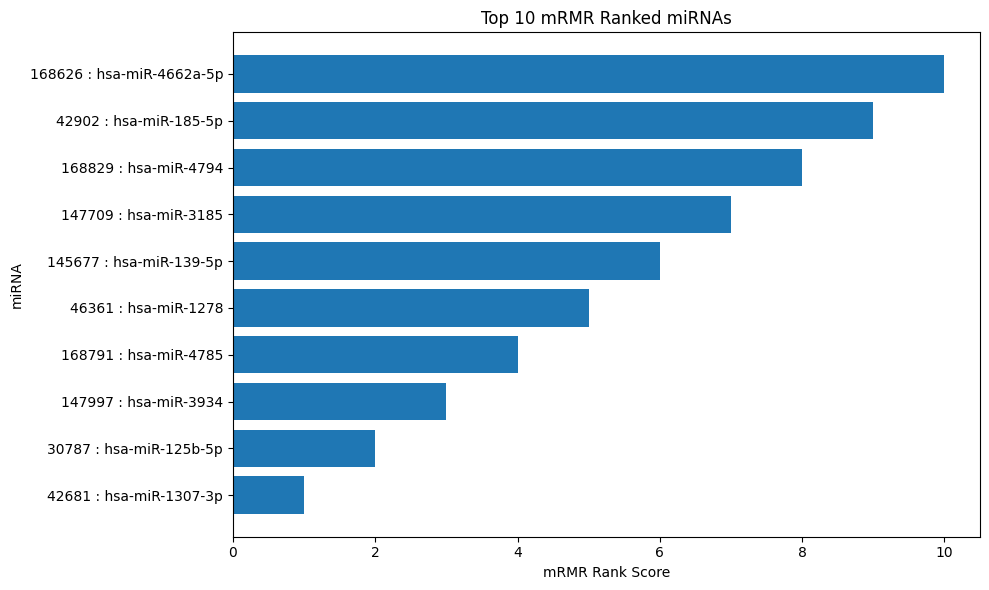

In [6]:
top10_mrmr = mrmr_ranking.head(10)
plot_df = top10_mrmr.copy()

plot_df["Score"] = list(range(10, 0, -1))
plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["miRNA"],
    plot_df["Score"]
)

plt.xlabel("mRMR Rank Score")
plt.ylabel("miRNA")
plt.title("Top 10 mRMR Ranked miRNAs")

plt.gca().invert_yaxis()
plt.savefig(
    "../figures/mRMR_top10",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [7]:
#Consensus Biomarker set 4
lasso_set = set(lasso_features["miRNA"])

rf_set = set(rf_importances.head(20)["miRNA"])

mi_set = set(mi_importances.head(20)["miRNA"])

xgb_set = set(xgb_importances.head(20)["miRNA"])

mrmr_set = set(mrmr_ranking.head(20)["miRNA"])

five_way_intersection = (
    lasso_set
    .intersection(rf_set)
    .intersection(mi_set)
    .intersection(xgb_set)
    .intersection(mrmr_set)
)

five_way_intersection

{'147709 : hsa-miR-3185', '168791 : hsa-miR-4785'}